# Masked Autoencoder (MAE) — Visual Intuition

**Research note:** [research/01-masked-autoencoder-mae.md](../research/01-masked-autoencoder-mae.md)

MAE masks ~75% of image patches and reconstructs the missing **pixels** from the visible
ones, using an asymmetric encoder (sees only visible patches) and a lightweight decoder.
This notebook builds intuition for *why MAE works* and *where the pixel target is wasteful* —
the gap that the rest of Tier 8 closes by predicting in **latent** space instead.

**What we will see:**

1. Why the mask ratio must be **high** — spatial redundancy makes low-ratio masking trivial.
2. Why the **asymmetric** encoder (visible-only) is cheap — compute scales with kept tokens.
3. Why the **pixel** target wastes capacity — high-frequency texture dominates the error budget.
4. Why **per-patch normalized** pixel targets help — they cancel brightness/contrast nuisance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: Why the mask ratio must be high

Natural images are spatially redundant: a missing patch is often predictable from its
neighbours by simple interpolation. If we mask only a little, the model can solve the task by
local copying — it never has to *understand* the scene. We test this directly.

We build a smooth patch grid (each patch is one scalar intensity from a low-frequency field),
mask a fraction `r` of patches at random, and reconstruct each masked patch by averaging its
**nearest visible neighbours** on the grid. The reconstruction error as a function of `r` tells
us when the task stops being trivially local.


In [2]:
# A smooth low-frequency field on a GxG grid of patches: each patch = one scalar intensity.
G = 24  # grid is G x G patches

yy, xx = np.meshgrid(np.linspace(0, 1, G), np.linspace(0, 1, G), indexing='ij')
# Sum of a few low-frequency sinusoids + Gaussian blobs => smooth, spatially redundant.
field = (np.sin(2 * np.pi * 1.5 * xx) * np.cos(2 * np.pi * 1.2 * yy)
         + 0.6 * np.sin(2 * np.pi * 0.8 * (xx + yy)))
for (cx, cy, s) in [(0.3, 0.3, 0.12), (0.7, 0.6, 0.18)]:
    field += 1.2 * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * s ** 2))
field = (field - field.mean()) / field.std()

coords = np.stack([yy.ravel(), xx.ravel()], axis=1) * (G - 1)  # grid coords in 'patch units'


def reconstruct_knn(values, visible_mask, k=4):
    # Reconstruct masked patches as the mean of their k nearest VISIBLE patches (grid distance).
    vis_idx = np.where(visible_mask)[0]
    vis_xy = coords[vis_idx]
    recon = values.copy()
    for j in np.where(~visible_mask)[0]:
        d = np.sum((vis_xy - coords[j]) ** 2, axis=1)
        nn = vis_idx[np.argsort(d)[:k]]
        recon[j] = values[nn].mean()
    return recon


flat = field.ravel()
ratios = np.linspace(0.1, 0.92, 12)
n_rep = 12
mse_mean, mse_std = [], []
for r in ratios:
    errs = []
    for rep in range(n_rep):
        rng = np.random.RandomState(100 + rep)
        vis = rng.rand(G * G) > r              # True = visible
        if vis.sum() < 4:
            continue
        recon = reconstruct_knn(flat, vis, k=4)
        m = ~vis
        errs.append(np.mean((recon[m] - flat[m]) ** 2))
    mse_mean.append(np.mean(errs))
    mse_std.append(np.std(errs))
mse_mean, mse_std = np.array(mse_mean), np.array(mse_std)
print(f"MSE at r=0.10: {mse_mean[0]:.3f}   MSE at r=0.75: {np.interp(0.75, ratios, mse_mean):.3f}"
      f"   MSE at r=0.92: {mse_mean[-1]:.3f}")

MSE at r=0.10: 0.017   MSE at r=0.75: 0.133   MSE at r=0.92: 0.376


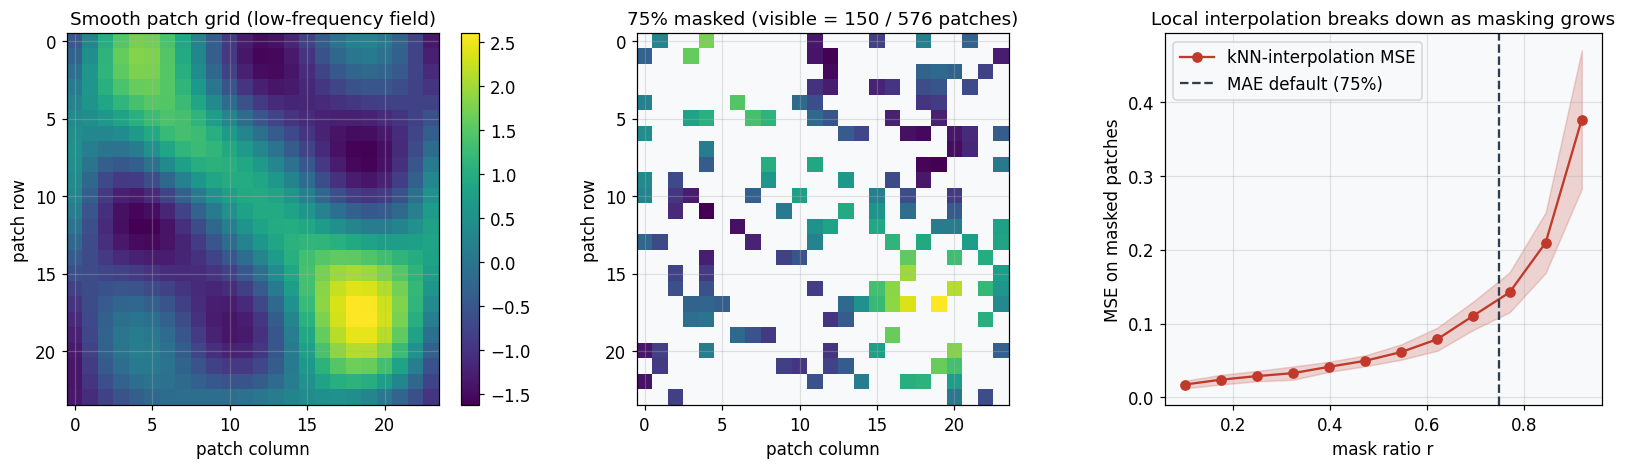

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) the smooth field
im = axes[0].imshow(field, cmap='viridis')
axes[0].set_title('Smooth patch grid (low-frequency field)')
axes[0].set_xlabel('patch column'); axes[0].set_ylabel('patch row')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# (b) one masked instance at r=0.75
rng = np.random.RandomState(7)
vis = rng.rand(G * G) > 0.75
masked_img = flat.copy(); masked_img[~vis] = np.nan
axes[1].imshow(masked_img.reshape(G, G), cmap='viridis')
axes[1].set_title(f'75% masked (visible = {vis.sum()} / {G*G} patches)')
axes[1].set_xlabel('patch column'); axes[1].set_ylabel('patch row')

# (c) error vs mask ratio
axes[2].plot(ratios, mse_mean, 'o-', color='#c0392b', label='kNN-interpolation MSE')
axes[2].fill_between(ratios, mse_mean - mse_std, mse_mean + mse_std, color='#c0392b', alpha=0.2)
axes[2].axvline(0.75, ls='--', color='#2c3e50', label='MAE default (75%)')
axes[2].set_title('Local interpolation breaks down as masking grows')
axes[2].set_xlabel('mask ratio r'); axes[2].set_ylabel('MSE on masked patches')
axes[2].legend()
plt.tight_layout(); plt.show()

### What you see

At low mask ratios the kNN-interpolation error is near zero: almost every masked patch still has
visible neighbours right next to it, so naive local copying reconstructs it. This is exactly the
regime MAE wants to *avoid* — the pretext task is trivial and teaches the encoder nothing about
global structure.

As `r` climbs past ~0.5 and toward 0.75, visible neighbours become sparse and far away; local
interpolation error rises sharply. To fill these large holes a model can no longer copy locally —
it must infer the **global** layout of the scene. That is why MAE deliberately masks ~75%: it
destroys spatial redundancy and forces holistic understanding, the opposite of BERT's ~15% (text
is far less redundant than pixels).


## Experiment 2: Why the asymmetric encoder is cheap

MAE's encoder runs **only on visible patches** — mask tokens are injected later, into the
lightweight decoder. So encoder cost scales with the *kept* fraction `(1 - r)`. For a Transformer
the MLP/linear part is roughly linear in the number of tokens, while self-attention is quadratic.
We plot the resulting speedup as a function of the mask ratio.


In [4]:
r = np.linspace(0.0, 0.9, 100)
kept = 1.0 - r
# Relative encoder cost vs. processing all tokens (r=0 baseline = 1.0).
cost_linear = kept            # MLP / projection: O(tokens)
cost_attn = kept ** 2         # self-attention: O(tokens^2)
speedup_linear = 1.0 / cost_linear
speedup_attn = 1.0 / cost_attn

for rr in [0.5, 0.75, 0.9]:
    print(f"r={rr:.2f}: linear-part speedup x{1/(1-rr):.1f}, attention-part speedup x{1/(1-rr)**2:.1f}")

r=0.50: linear-part speedup x2.0, attention-part speedup x4.0
r=0.75: linear-part speedup x4.0, attention-part speedup x16.0
r=0.90: linear-part speedup x10.0, attention-part speedup x100.0


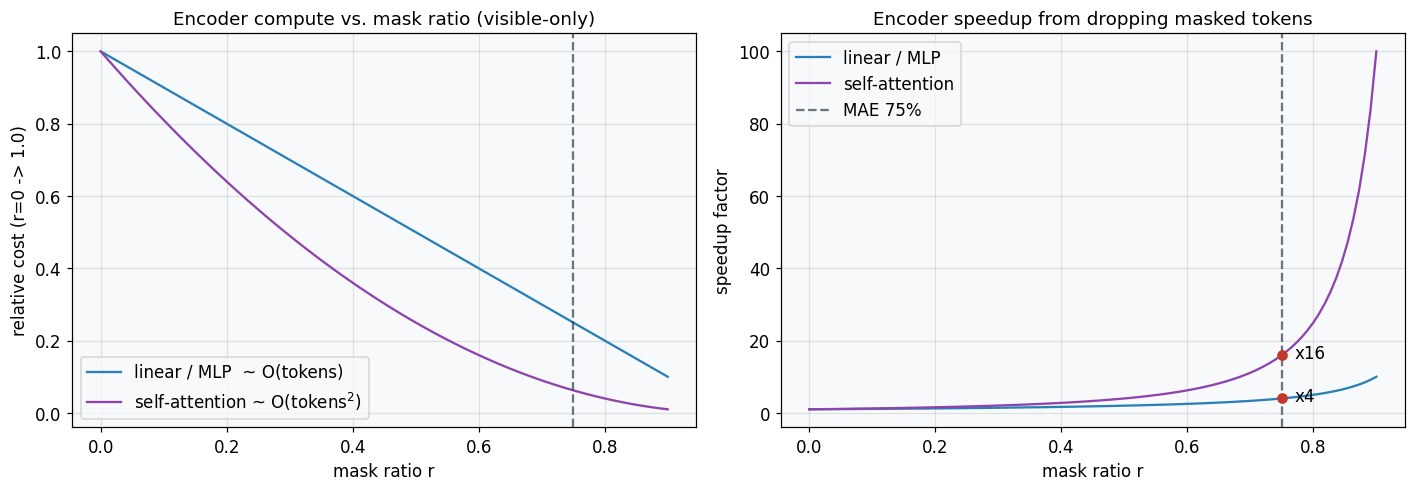

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(r, cost_linear, label='linear / MLP  ~ O(tokens)', color='#2980b9')
axes[0].plot(r, cost_attn, label='self-attention ~ O(tokens$^2$)', color='#8e44ad')
axes[0].axvline(0.75, ls='--', color='#2c3e50', alpha=0.7)
axes[0].set_title('Encoder compute vs. mask ratio (visible-only)')
axes[0].set_xlabel('mask ratio r'); axes[0].set_ylabel('relative cost (r=0 -> 1.0)')
axes[0].legend()

axes[1].plot(r, speedup_linear, label='linear / MLP', color='#2980b9')
axes[1].plot(r, speedup_attn, label='self-attention', color='#8e44ad')
axes[1].axvline(0.75, ls='--', color='#2c3e50', alpha=0.7, label='MAE 75%')
axes[1].scatter([0.75, 0.75], [4.0, 16.0], color='#c0392b', zorder=5)
axes[1].annotate('x4', (0.75, 4.0), textcoords='offset points', xytext=(8, -2))
axes[1].annotate('x16', (0.75, 16.0), textcoords='offset points', xytext=(8, -2))
axes[1].set_title('Encoder speedup from dropping masked tokens')
axes[1].set_xlabel('mask ratio r'); axes[1].set_ylabel('speedup factor')
axes[1].legend()
plt.tight_layout(); plt.show()

### What you see

Because the encoder never sees masked tokens, its workload shrinks with the kept fraction. At the
default 75% masking it processes only a quarter of the tokens: the linear/MLP part gets ~4x cheaper
and the quadratic attention part up to ~16x cheaper. In practice MAE reports a 3x+ end-to-end
speedup (the decoder and fixed overheads dilute the ideal numbers).

This is the second design that makes MAE *scalable*: high masking is not just a harder pretext task
(Experiment 1), it is also what makes a huge encoder (ViT-Huge) affordable to pretrain. The pattern
— **drop tokens before the expensive stage** — is a general runtime-efficiency idea, not specific to
MAE.


## Experiment 3: The pixel target wastes capacity on texture

MAE's loss is pixel MSE. But a patch's pixels are *low-frequency structure* (the semantic shape)
plus *high-frequency texture* (surface detail, noise) that is largely irrelevant to downstream
decisions. We show that as texture amplitude grows, it dominates the pixel-error budget: a model
that captures the semantics perfectly but ignores texture is still heavily penalized — so the
pixel objective *forces* it to spend capacity modelling texture.


In [6]:
H = 64
ax1 = np.linspace(0, 1, H)
gx, gy = np.meshgrid(ax1, ax1)
# Low-frequency 'semantic' structure S (what we care about).
S = np.sin(2 * np.pi * 1.5 * gx) * np.cos(2 * np.pi * 1.5 * gy) + 0.5 * gx
S = (S - S.mean()) / S.std()

# High-frequency 'texture' T (surface detail / noise, semantically irrelevant).
rng = np.random.RandomState(0)
T = rng.randn(H, H)
T = (T - T.mean()) / T.std()

amps = np.linspace(0.0, 1.5, 16)
# A 'semantic-only' reconstruction predicts S and leaves texture at its mean (0).
mse_semantic_only = []
for a in amps:
    img = S + a * T
    recon = S                      # perfect semantics, no texture
    mse_semantic_only.append(np.mean((img - recon) ** 2))
mse_semantic_only = np.array(mse_semantic_only)
print(f"At texture amp a=0.0  pixel-MSE={mse_semantic_only[0]:.3f}")
print(f"At texture amp a=1.0  pixel-MSE={np.interp(1.0, amps, mse_semantic_only):.3f}  (= a^2 * var(T))")

At texture amp a=0.0  pixel-MSE=0.000
At texture amp a=1.0  pixel-MSE=1.000  (= a^2 * var(T))


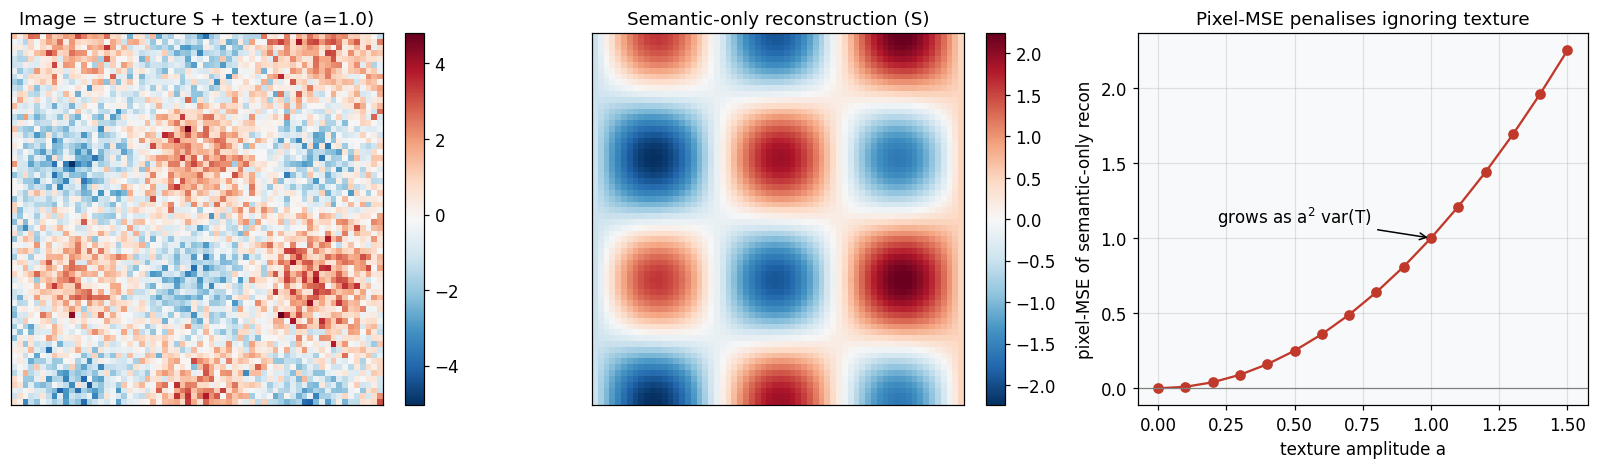

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

a_show = 1.0
img = S + a_show * T
im0 = axes[0].imshow(img, cmap='RdBu_r'); axes[0].set_title('Image = structure S + texture (a=1.0)')
axes[0].set_xticks([]); axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(S, cmap='RdBu_r'); axes[1].set_title('Semantic-only reconstruction (S)')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].plot(amps, mse_semantic_only, 'o-', color='#c0392b')
axes[2].axhline(0, color='gray', lw=0.8)
axes[2].set_title('Pixel-MSE penalises ignoring texture')
axes[2].set_xlabel('texture amplitude a'); axes[2].set_ylabel('pixel-MSE of semantic-only recon')
axes[2].annotate('grows as a$^2$ var(T)', (1.0, np.interp(1.0, amps, mse_semantic_only)),
                 textcoords='offset points', xytext=(-140, 10),
                 arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); plt.show()

### What you see

The middle panel is a *perfect* semantic reconstruction — it has the full low-frequency structure,
just no texture. Yet its pixel-MSE against the textured image grows quadratically with texture
amplitude (it equals `a^2 * var(T)`). Under a pixel objective, this perfectly-semantic model looks
*bad*, and gradient descent will push it to start fitting the high-frequency texture to drive the
loss down — spending representational capacity on detail that carries little semantic signal.

This is the core critique that motivates the whole tier: pixel reconstruction conflates *what
matters* (structure) with *what doesn't* (texture/noise) and budgets error by raw variance, not by
relevance. Predicting in **latent** space (JEPA) removes the texture term entirely — you only
predict the part of the representation that is predictable and semantic.


## Experiment 4: Why per-patch normalized targets help

MAE found that using **per-patch normalized pixels** (subtract each patch's mean, divide by its std)
as the target improves the learned representation. Intuition: absolute brightness and contrast are
nuisance factors; normalizing cancels them so the loss rewards *local structure* instead. We make
this visible by measuring how raw vs. normalized patch-MSE responds to pure brightness/contrast
changes that leave structure untouched.


In [8]:
# A reference patch with clear internal structure.
p = 8
ay = np.linspace(-1, 1, p)
gx2, gy2 = np.meshgrid(ay, ay)
base = np.sin(3 * gx2) + gy2          # structural pattern
base = (base - base.mean()) / base.std()


def patch_norm(x):
    return (x - x.mean()) / (x.std() + 1e-6)


brightness = np.linspace(-2, 2, 41)   # additive offset
contrast = np.linspace(0.3, 2.5, 41)  # multiplicative scale
raw_mse = np.zeros((len(contrast), len(brightness)))
norm_mse = np.zeros_like(raw_mse)
base_n = patch_norm(base)
for i, c in enumerate(contrast):
    for j, b in enumerate(brightness):
        twin = c * base + b           # SAME structure, only brightness/contrast changed
        raw_mse[i, j] = np.mean((twin - base) ** 2)
        norm_mse[i, j] = np.mean((patch_norm(twin) - base_n) ** 2)
print(f"raw-MSE range:        [{raw_mse.min():.2f}, {raw_mse.max():.2f}]")
print(f"normalized-MSE range: [{norm_mse.min():.4f}, {norm_mse.max():.4f}]")

raw-MSE range:        [0.00, 6.25]
normalized-MSE range: [0.0000, 0.0000]


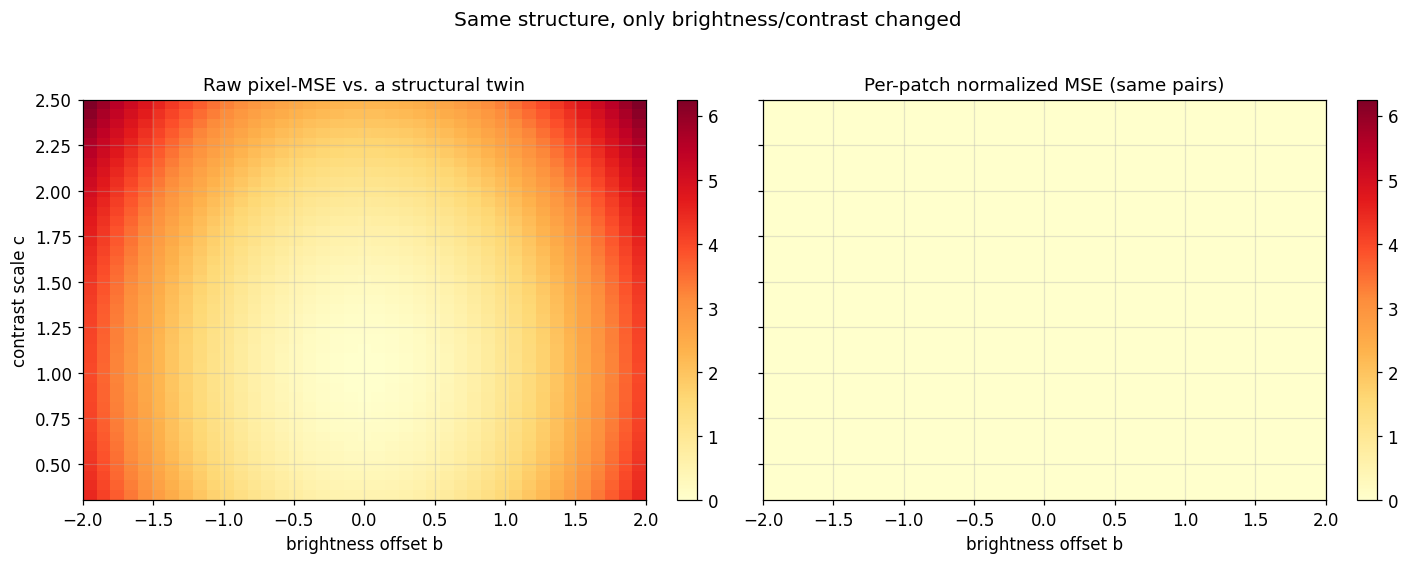

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ext = [brightness[0], brightness[-1], contrast[0], contrast[-1]]
vmax = raw_mse.max()

im0 = axes[0].imshow(raw_mse, origin='lower', aspect='auto', extent=ext, cmap='YlOrRd', vmin=0, vmax=vmax)
axes[0].set_title('Raw pixel-MSE vs. a structural twin')
axes[0].set_xlabel('brightness offset b'); axes[0].set_ylabel('contrast scale c')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(norm_mse, origin='lower', aspect='auto', extent=ext, cmap='YlOrRd', vmin=0, vmax=vmax)
axes[1].set_title('Per-patch normalized MSE (same pairs)')
axes[1].set_xlabel('brightness offset b')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle('Same structure, only brightness/contrast changed', y=1.02)
plt.tight_layout(); plt.show()

### What you see

Both panels compare patches that share **identical structure** and differ only in brightness
(horizontal) and contrast (vertical). Under raw pixel-MSE (left), these structural twins look very
different — error blows up wherever brightness or contrast shifts, even though nothing semantic
changed. Under per-patch normalization (right) the same pairs collapse to near-zero error: the
nuisance factors are divided out, and the target now measures *local contrast structure* only.

This is why MAE's normalized-pixel target yields better features: it nudges the pixel objective a
step toward semantics by discarding absolute intensity. But note it is only a partial fix — texture
(Experiment 3) is still in the target. Fully removing the irrelevant part requires leaving pixel
space altogether, which is the move the rest of Tier 8 makes.


## Summary / Key Takeaways

- **High mask ratio is essential (Exp 1).** Images are spatially redundant; low masking is solved by
  trivial local interpolation. Masking ~75% destroys redundancy and forces the encoder to infer
  global structure — a genuinely hard pretext task.
- **The asymmetric encoder makes it cheap (Exp 2).** Running the encoder on visible patches only
  cuts compute by ~4x (linear) to ~16x (attention) at 75% masking, enabling huge-model pretraining.
- **The pixel target is wasteful (Exp 3).** Pixel-MSE budgets error by raw variance, so it forces the
  model to spend capacity on high-frequency texture that is irrelevant to semantics.
- **Normalized targets are a partial fix (Exp 4).** Per-patch normalization cancels brightness/
  contrast nuisance, but texture remains in the target.
- **Bridge to Tier 8.** MAE is the strong *pixel-prediction* baseline. Its limitations motivate
  predicting in **latent** space — which immediately raises the question of the next note:
  *representation collapse*.
